In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../bdhs-dataset/dataset.csv')
df.head()

,V020,S111A,V501,HV104,SB267,SB236,SB240,WBP24,WBP25,WBP16,...,V228,V743A,V743B,V743D,V743F,V744A,V744B,V744C,V744D,V744E
0,1,1,1,2,139.0,0.0,NaN,129.0,97.0,1.0,...,1,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
1,1,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1.0,2.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0
2,1,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
4,1,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.nunique()

V020         1
S111A        5
V501         4
HV104        1
SB267      201
SB236        3
SB240        2
WBP24      118
WBP25       77
WBP16        2
WBP19        2
HA40      1945
MTH22       28
MTH24       22
V133        19
V149         6
V106         4
V190         5
V190A        5
V191     21815
V191A    21865
V714         2
V731         4
V716        17
V717        10
V704        18
V705        10
V012        35
V013         7
V024         8
V025         2
V026         3
V511        39
V513         7
V130         5
V201        12
V212        33
V218        11
V219        11
V136        23
V137         7
V138         6
MTH10        6
V481         2
V157         3
V158         3
V159         3
V171A        3
V312        16
V313         4
V228         2
V743A        5
V743B        5
V743D        5
V743F        5
V744A        3
V744B        3
V744C        3
V744D        3
V744E        3
dtype: int64

In [4]:
df['V020'].value_counts()

V020
1    30078
Name: count, dtype: int64

In [5]:
df['HV104'].value_counts()

HV104
2    30078
Name: count, dtype: int64

In [6]:
df.columns

Index(['V020', 'S111A', 'V501', 'HV104', 'SB267', 'SB236', 'SB240', 'WBP24',
       'WBP25', 'WBP16', 'WBP19', 'HA40', 'MTH22', 'MTH24', 'V133', 'V149',
       'V106', 'V190', 'V190A', 'V191', 'V191A', 'V714', 'V731', 'V716',
       'V717', 'V704', 'V705', 'V012', 'V013', 'V024', 'V025', 'V026', 'V511',
       'V513', 'V130', 'V201', 'V212', 'V218', 'V219', 'V136', 'V137', 'V138',
       'MTH10', 'V481', 'V157', 'V158', 'V159', 'V171A', 'V312', 'V313',
       'V228', 'V743A', 'V743B', 'V743D', 'V743F', 'V744A', 'V744B', 'V744C',
       'V744D', 'V744E'],
      dtype='str')

In [7]:
from tools.recode import recode

print(len(recode.keys()))
print(len(df.columns))

60
60


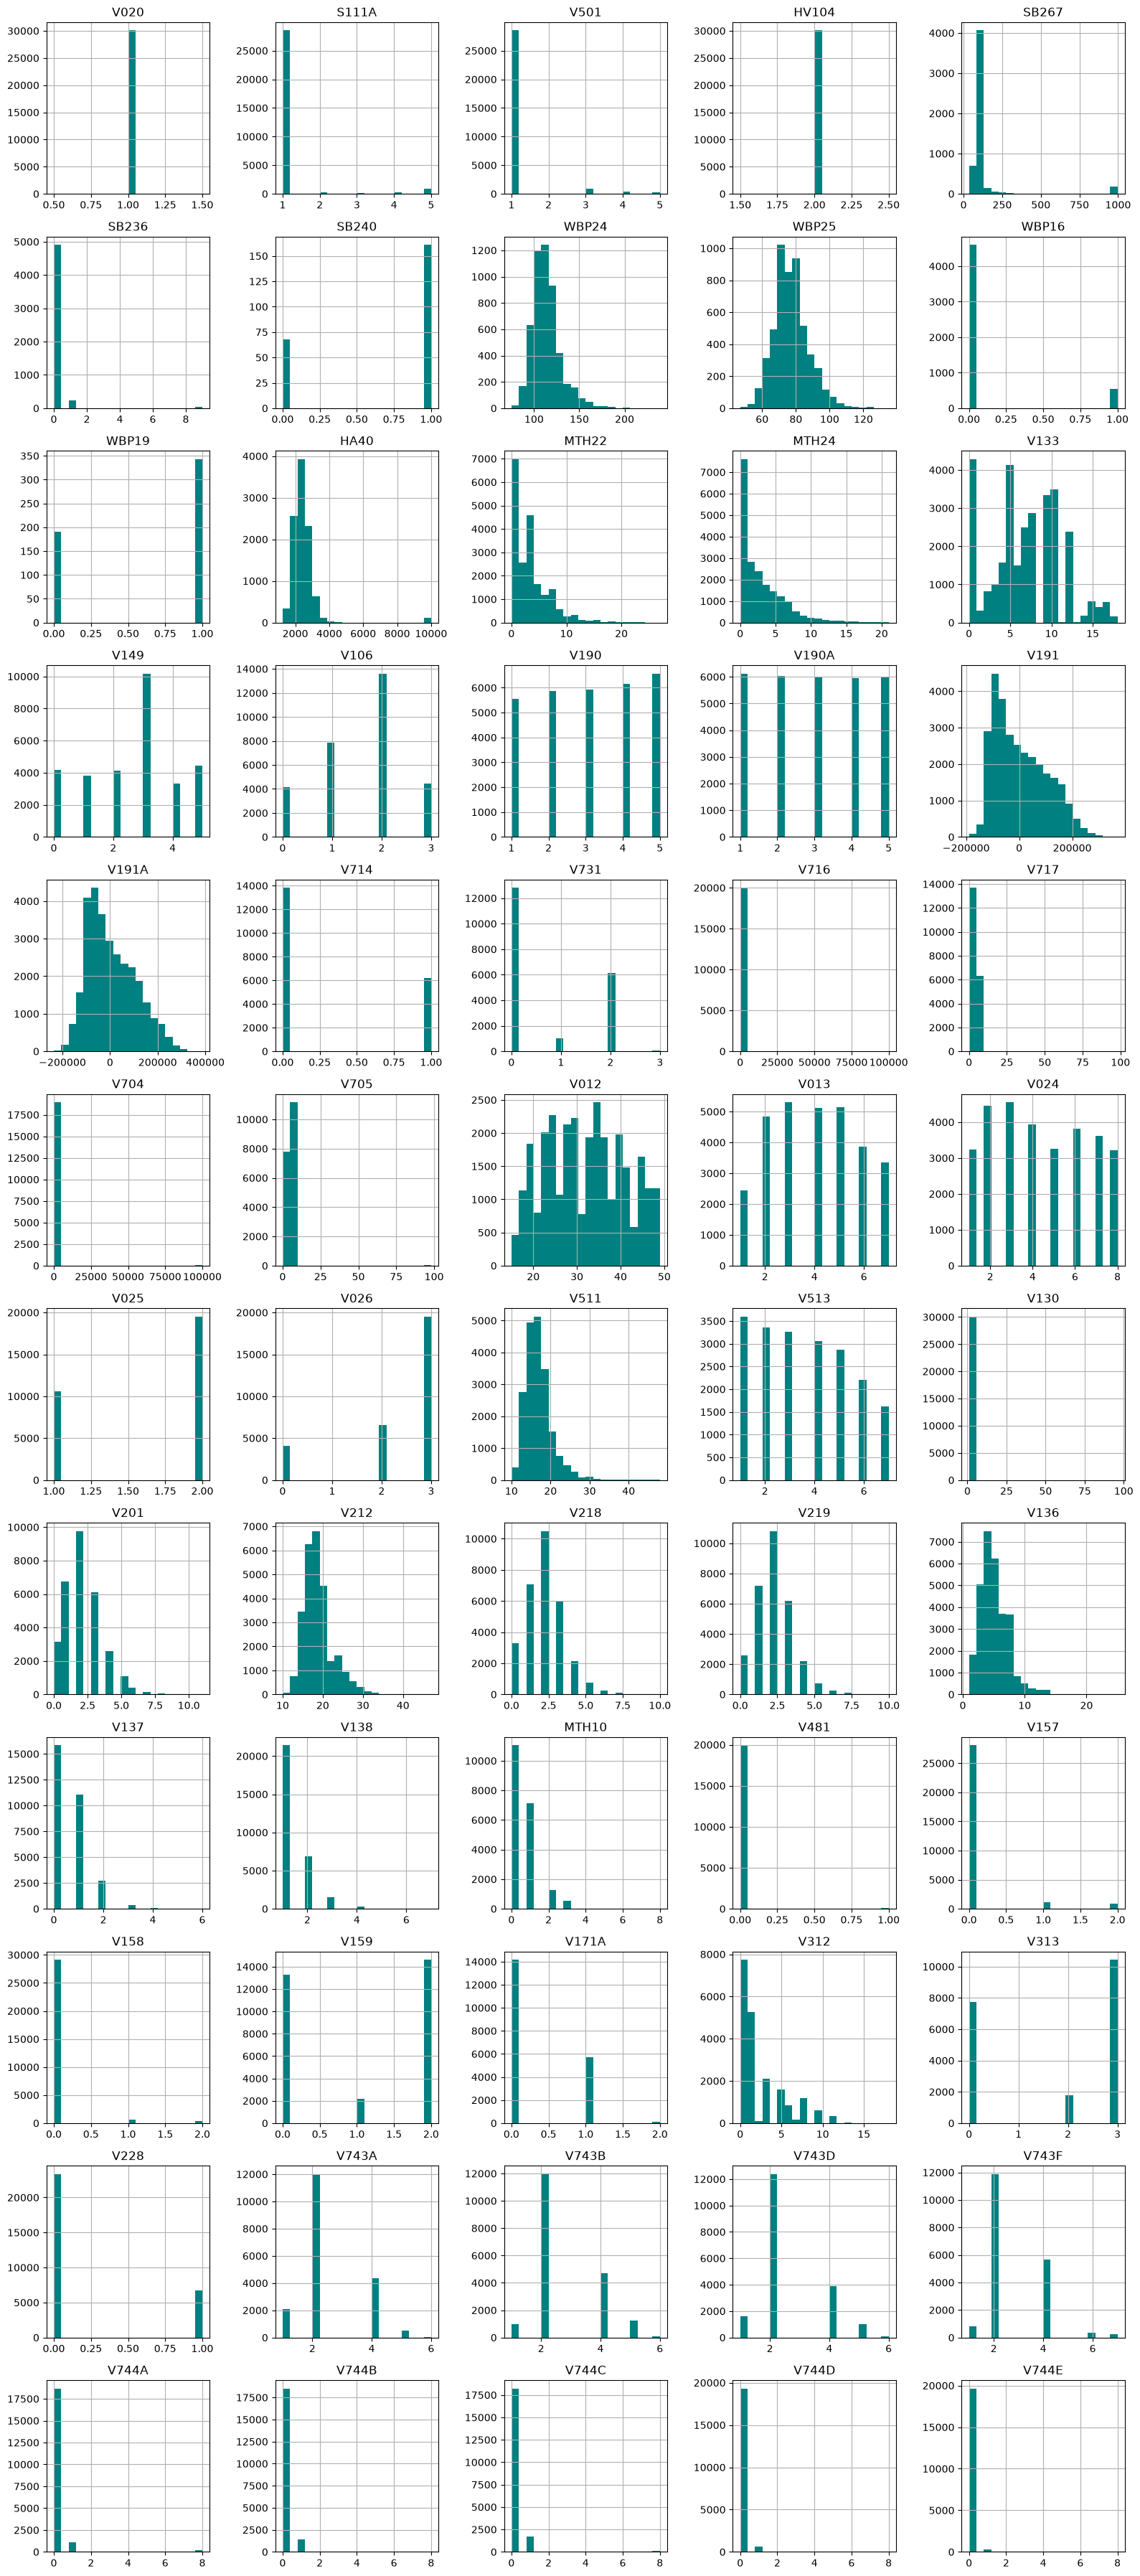

In [8]:
cols_per_row = 5
num_rows = len(df.columns) / cols_per_row
num_rows = int(num_rows) if num_rows == int(num_rows) else int(num_rows) + 1

df.hist(bins=20, figsize=(16, 3 * num_rows), color="teal", layout=(num_rows, cols_per_row))
plt.tight_layout()
plt.show()

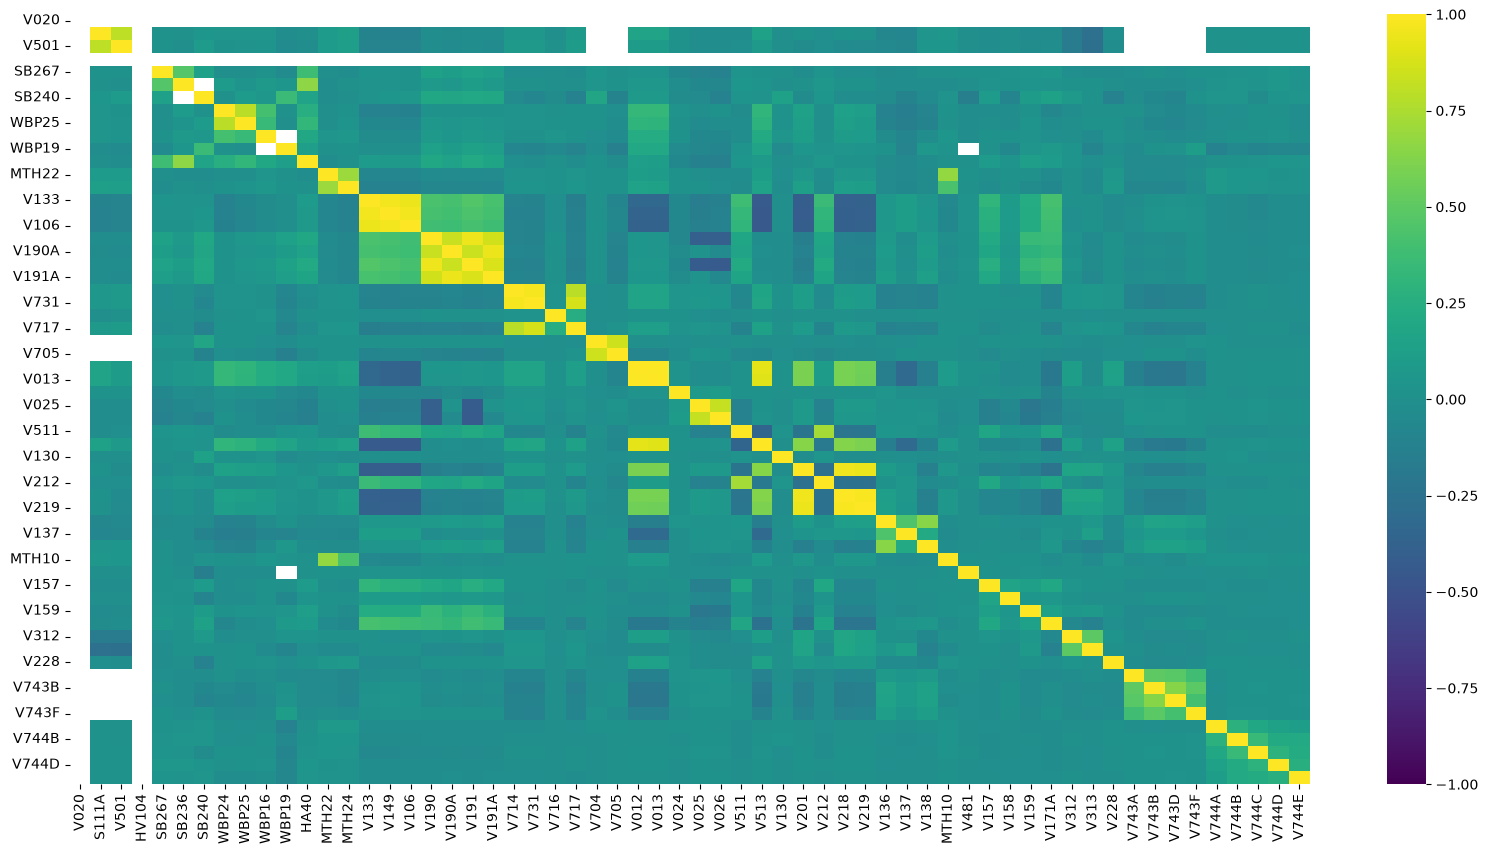

In [9]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), vmin=-1, vmax=1, cmap='viridis', annot=False)
plt.show()

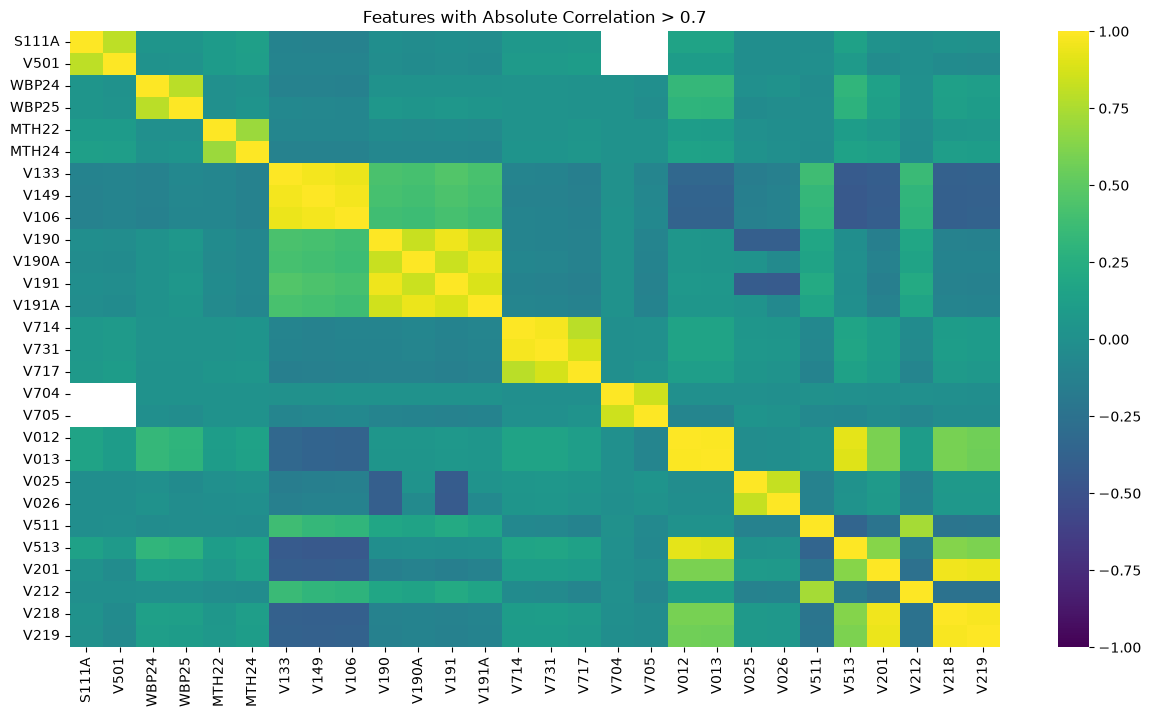

In [10]:
threshold = 0.70
corr = df.corr()
corr_abs = corr.abs()
mask = (corr_abs > threshold) & (corr_abs < 1.0)
high_corr_features = corr.columns[mask.any()].tolist()
filtered_corr = corr.loc[high_corr_features, high_corr_features]

plt.figure(figsize=(15, 8))
sns.heatmap(filtered_corr, vmin=-1, vmax=1, cmap='viridis', annot=False, fmt='.2f')
plt.title(f'Features with Absolute Correlation > {threshold}')
plt.show()

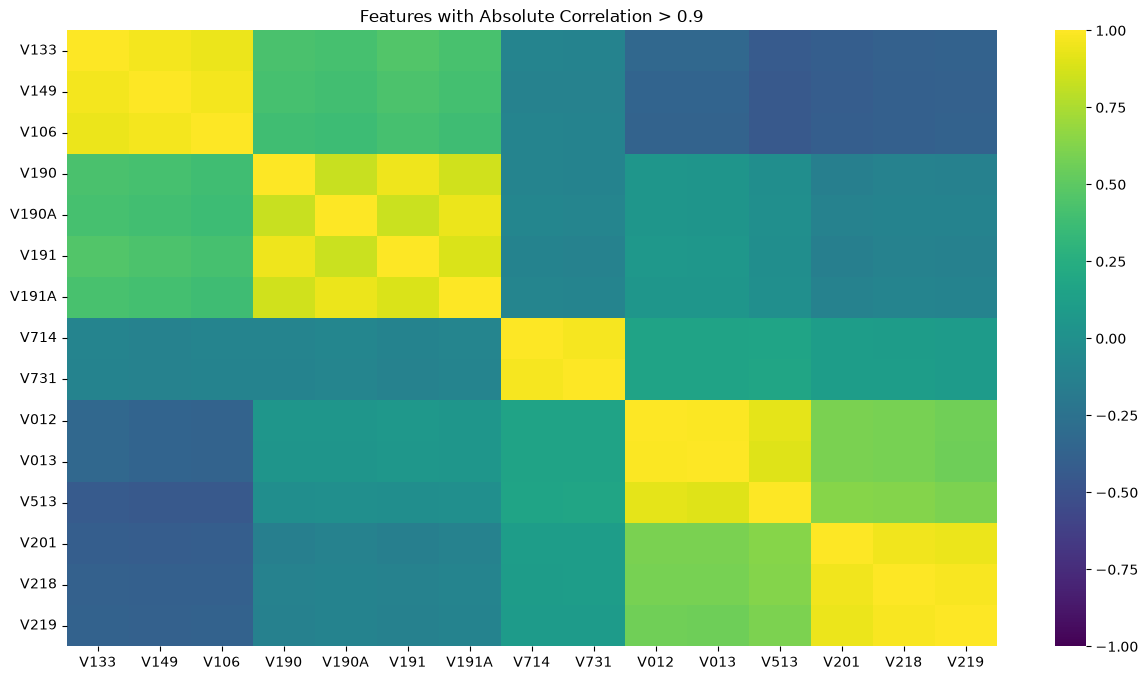

In [11]:
threshold = 0.90
corr = df.corr()
corr_abs = corr.abs()
mask = (corr_abs > threshold) & (corr_abs < 1.0)
high_corr_features = corr.columns[mask.any()].tolist()
filtered_corr = corr.loc[high_corr_features, high_corr_features]

plt.figure(figsize=(15, 8))
sns.heatmap(filtered_corr, vmin=-1, vmax=1, cmap='viridis', annot=False, fmt='.2f')
plt.title(f'Features with Absolute Correlation > {threshold}')
plt.show()

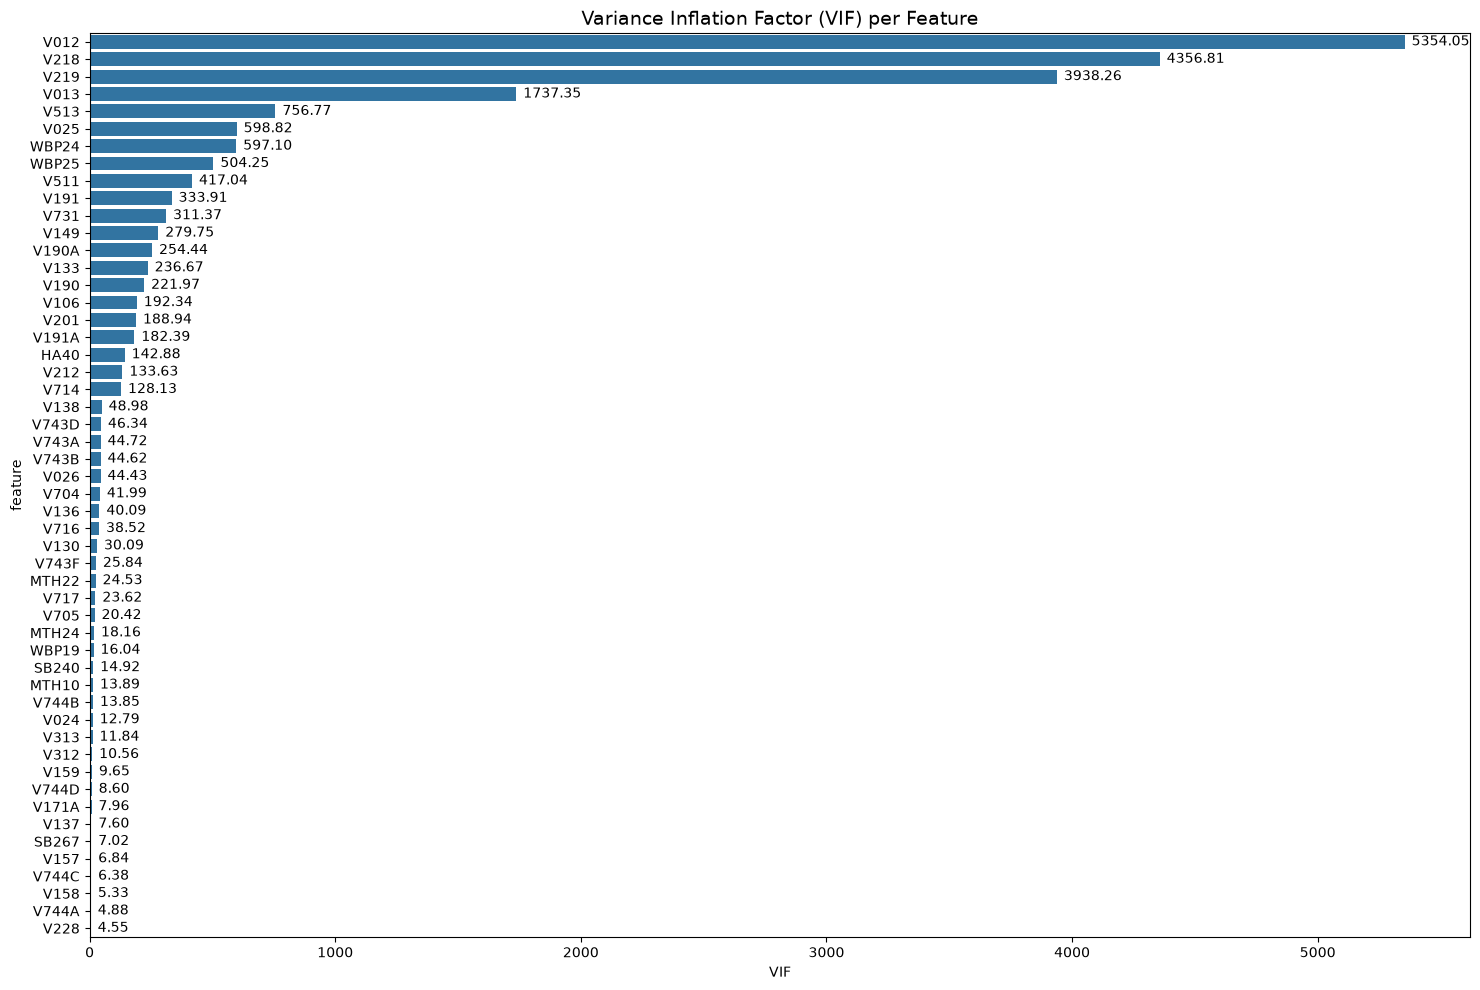

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

temp = df.select_dtypes(include=['number']).dropna()
temp = temp.loc[:, temp.nunique() > 1]
vif_data = pd.DataFrame()
vif_data["feature"] = temp.columns
vif_data["VIF"] = [variance_inflation_factor(temp.values, i) for i in range(temp.shape[1])]

plt.figure(figsize=(15, 10))
ax = sns.barplot(data=vif_data.sort_values(by="VIF", ascending=False), x="VIF", y="feature")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=5, fontsize=10)
plt.title("Variance Inflation Factor (VIF) per Feature", fontsize=14)
plt.tight_layout()
plt.show()

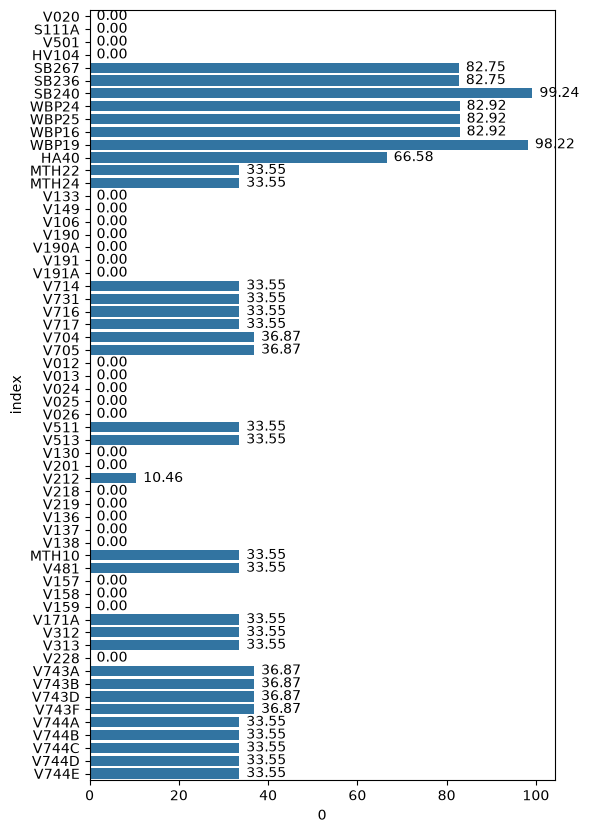

In [13]:
plt.figure(figsize=(6, 10))
ax = sns.barplot(data=(df.isna().sum(axis=0) / df.shape[0] * 100).reset_index(), x=0, y="index")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=5, fontsize=10)
plt.show()

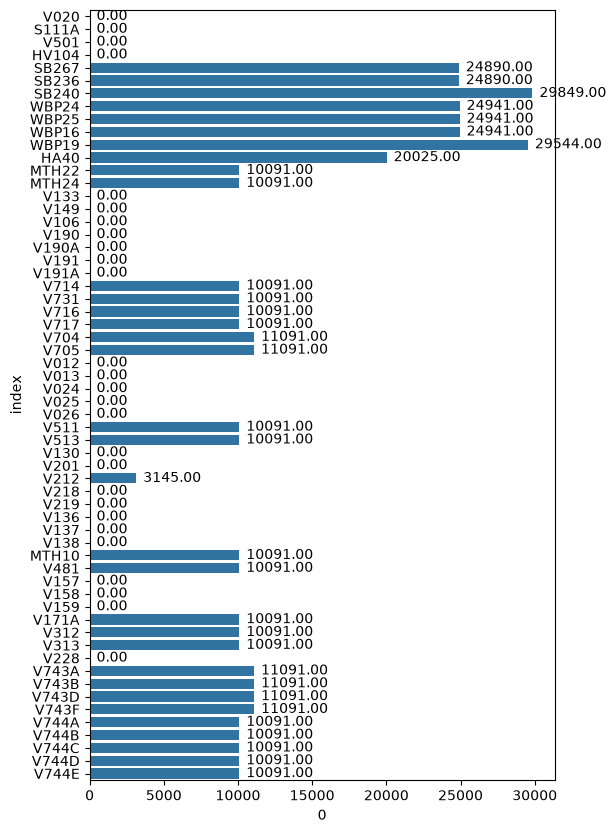

In [14]:
plt.figure(figsize=(6, 10))
ax = sns.barplot(data=(df.isna().sum(axis=0)).reset_index(), x=0, y="index")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=5, fontsize=10)
plt.show()

In [15]:
df.shape

(30078, 60)